# Notebook 2 — Random Forest con selección de características e interpretabilidad exhaustiva
### Tuberculosis bovina

Ajusta un **Random Forest** como modelo principal, aplica un **pipeline de selección de
características** basado en importancia de permutación + eliminación hacia atrás guiada
por error de validación cruzada Leave-One-Farm-Out, y realiza un **análisis exhaustivo
de interpretabilidad** con las variables seleccionadas: SHAP, PDP, ICE, ALE y
contrafactuales.

> **Marco de honestidad estadística.** Con *n*=106 y **4 explotaciones**, toda la selección
> de características y el preprocesamiento se realizan **dentro** de CV para evitar fugas de
> información. Las métricas reportadas son LOFO (Leave-One-Farm-Out), que estiman la
> generalización a granjas nuevas.


## 1. Setup e importaciones

In [12]:
# !pip install -q scikit-learn shap matplotlib seaborn statsmodels
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.model_selection import LeaveOneGroupOut, StratifiedKFold, cross_val_predict
from sklearn.metrics import (average_precision_score, roc_auc_score,
                             brier_score_loss, matthews_corrcoef, recall_score)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
import shap
import tb_utils as tb

PALETTE = tb.set_plot_style()
tb.set_seeds(tb.SEED)

import os
DATA = "../BD.csv"
df = tb.clean(tb.load_raw(DATA))

d = tb.target_subset(df, "Lesiones_TB")
X_all = d[tb.MODEL_FEATURES].copy()
y     = d["Lesiones_TB"].astype(int).values
g     = d[tb.GROUP_COL].values

print(f"Dataset: n={len(y)}, prevalencia={y.mean():.3f}")
print(f"Features ({len(tb.MODEL_FEATURES)}): {tb.MODEL_FEATURES}")
print(f"Línea base PR-AUC (prevalencia) = {y.mean():.3f}")
print(f"Granjas: {np.unique(g)}")


Dataset: n=106, prevalencia=0.613
Features (8): ['VITAMINA_D', 'CALCIO', 'PIROPLASMA_Q_log', 'EDAD', 'PIROPLASMA', 'THEILERIA', 'ANAPLASMA', 'RAZA2']
Línea base PR-AUC (prevalencia) = 0.613
Granjas: ['VA32D' 'VC30D' 'VC94C' 'WZ72B']


## 2. Random Forest — modelo y justificación

Con *n*=106 elegimos **Random Forest** por varias razones:
- Maneja naturalmente variables mixtas (numéricas + categóricas) y valores faltantes (tras imputación).
- `class_weight="balanced"` corrige el desbalance de clases sin muestreo adicional.
- `min_samples_leaf=5` actúa como regularización implícita crucial con *n* pequeño.
- Proporciona importancia de permutación robusta y es compatible con SHAP `TreeExplainer`.
- A diferencia de XGBoost, no requiere tuning extenso de hiperparámetros para ser razonable.

La imputación y el escalado van **dentro** del `Pipeline` para evitar fuga de información.


In [13]:
def make_rf(n_estimators=500, min_samples_leaf=5):
    return RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=None,
        min_samples_leaf=min_samples_leaf,
        max_features="sqrt",
        class_weight="balanced",
        random_state=tb.SEED,
        n_jobs=-1,
        oob_score=True,
    )

def make_pipe(feature_list):
    """Pipeline con preprocesador adaptado al subset de features."""
    num_f = [f for f in feature_list if f in tb.NUM_FEATURES]
    cat_f = [f for f in feature_list if f in tb.CAT_FEATURES]
    prep  = tb.make_preprocessor(numeric=num_f, categorical=cat_f, scale=False)
    return Pipeline([("prep", prep), ("clf", make_rf())])

def lofo_metrics(feature_list, X, y, g):
    """PR-AUC, ROC y MCC medios en Leave-One-Farm-Out CV."""
    Xs = X[list(feature_list)]
    pipe_tmpl = make_pipe(feature_list)
    prauc_scores, roc_scores, mcc_scores = [], [], []
    for tr, te in LeaveOneGroupOut().split(Xs, y, g):
        if len(np.unique(y[tr])) < 2 or len(np.unique(y[te])) < 2:
            continue
        pipe_fold = clone(pipe_tmpl)
        pipe_fold.fit(Xs.iloc[tr], y[tr])
        p    = pipe_fold.predict_proba(Xs.iloc[te])[:, 1]
        pred = (p >= 0.5).astype(int)
        prauc_scores.append(average_precision_score(y[te], p))
        roc_scores.append(roc_auc_score(y[te], p) if len(np.unique(y[te])) > 1 else np.nan)
        mcc_scores.append(matthews_corrcoef(y[te], pred))
    return {
        "prauc_mean": float(np.mean(prauc_scores)),
        "prauc_std":  float(np.std(prauc_scores)),
        "roc_mean":   float(np.nanmean(roc_scores)),
        "mcc_mean":   float(np.mean(mcc_scores)),
        "n_folds":    len(prauc_scores),
    }

# Evaluación baseline — todos los features
print("Evaluación baseline RF (todos los features, LOFO):")
baseline = lofo_metrics(tb.MODEL_FEATURES, X_all, y, g)
print(f"  PR-AUC = {baseline['prauc_mean']:.3f} ± {baseline['prauc_std']:.3f}")
print(f"  ROC    = {baseline['roc_mean']:.3f}")
print(f"  MCC    = {baseline['mcc_mean']:.3f}")
print(f"  Folds  = {baseline['n_folds']}")
print(f"  Línea base (prevalencia) = {y.mean():.3f}")


Evaluación baseline RF (todos los features, LOFO):
  PR-AUC = 0.719 ± 0.206
  ROC    = 0.569
  MCC    = 0.104
  Folds  = 4
  Línea base (prevalencia) = 0.613


## 3. Pipeline de selección de características

**Algoritmo:**
1. Ajustar RF sobre todos los features en el conjunto completo para obtener el **ranking de
   importancia de permutación** (orden de eliminación).
2. **Eliminación hacia atrás**: empezando con todos los features, eliminar iterativamente el
   menos importante, calculando el error CV LOFO en cada paso.
3. **Selección**: conservar el subconjunto más pequeño cuya PR-AUC LOFO esté dentro de 1 DE
   del máximo observado (regla de parsimonia). Estos son los features cuya eliminación individual
   causaría una caída significativa de rendimiento.


Paso 1: Ajustando RF completo para ranking de importancia...
OOB Score (en muestra): 0.481

Ranking por importancia de permutación (modelo completo, en muestra):
                 pretty  imp_mean  imp_std
             Vitamina D    0.0954   0.0180
                 Calcio    0.0817   0.0133
            Edad (años)    0.0562   0.0189
log(1+Carga piroplasma)    0.0446   0.0108
                   Raza    0.0237   0.0057
     Anaplasma spp. (+)    0.0161   0.0070
         Piroplasma (+)    0.0130   0.0039
     Theileria spp. (+)    0.0037   0.0016


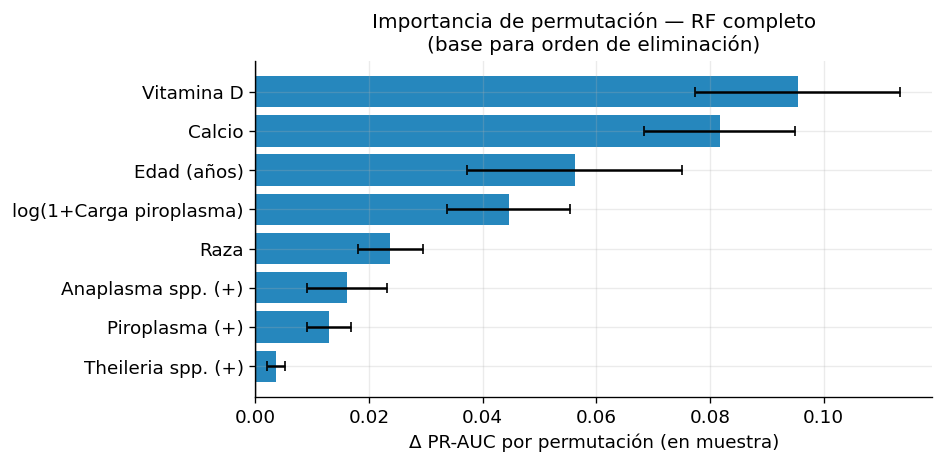

In [14]:
# ── Paso 1: Importancia de permutación sobre modelo completo ─────────────────
print("Paso 1: Ajustando RF completo para ranking de importancia...")
full_pipe = make_pipe(tb.MODEL_FEATURES).fit(X_all, y)
print(f"OOB Score (en muestra): {full_pipe.named_steps['clf'].oob_score_:.3f}")

pi = permutation_importance(
    full_pipe, X_all, y,
    scoring="average_precision",
    n_repeats=50,
    random_state=tb.SEED,
    n_jobs=-1,
)
imp_df = pd.DataFrame({
    "feature":   tb.MODEL_FEATURES,
    "imp_mean":  pi.importances_mean,
    "imp_std":   pi.importances_std,
}).sort_values("imp_mean", ascending=False).reset_index(drop=True)
imp_df["pretty"] = imp_df.feature.map(lambda f: tb.PRETTY.get(f, f))

print("\nRanking por importancia de permutación (modelo completo, en muestra):")
print(imp_df[["pretty", "imp_mean", "imp_std"]].round(4).to_string(index=False))

# Visualización
fig, ax = plt.subplots(figsize=(8, 4))
order = imp_df.sort_values("imp_mean")
ax.barh(order.pretty, order.imp_mean, xerr=order.imp_std,
        color=PALETTE[0], capsize=3, alpha=0.85)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("Δ PR-AUC por permutación (en muestra)")
ax.set_title("Importancia de permutación — RF completo\n(base para orden de eliminación)")
plt.tight_layout()
plt.savefig("figures/fig5_perm_importance_full.png")
plt.show()


In [15]:
# ── Paso 2: Eliminación hacia atrás ─────────────────────────────────────────
# Orden de eliminación = de menos a más importante según ranking del paso 1
elim_order = imp_df.sort_values("imp_mean", ascending=True)["feature"].tolist()
print(f"Orden de eliminación (primero el menos importante):")
for i, f in enumerate(elim_order):
    print(f"  {i+1}. {f} ({tb.PRETTY.get(f, f)})")

print("\nPaso 2: Eliminación hacia atrás con LOFO CV (puede tardar 2-3 min)...\n")

current_features = tb.MODEL_FEATURES.copy()
history = []

# Baseline
m = lofo_metrics(current_features, X_all, y, g)
history.append({"n": len(current_features), "features": current_features.copy(),
                "removed": "—(baseline)", **m})
print(f"  {len(current_features):2d} features [baseline] "
      f"PR-AUC={m['prauc_mean']:.3f}±{m['prauc_std']:.3f}")

for feat in elim_order:
    if feat not in current_features or len(current_features) <= 1:
        break
    test_feats = [f for f in current_features if f != feat]
    m = lofo_metrics(test_feats, X_all, y, g)
    history.append({"n": len(test_feats), "features": test_feats.copy(),
                    "removed": feat, **m})
    delta = m["prauc_mean"] - history[0]["prauc_mean"]
    print(f"  {len(test_feats):2d} features [-{feat:20s}] "
          f"PR-AUC={m['prauc_mean']:.3f}±{m['prauc_std']:.3f}  "
          f"Δ_baseline={delta:+.3f}")
    current_features = test_feats

hist_df = pd.DataFrame(history)
print("\nEliminación completada.")


Orden de eliminación (primero el menos importante):
  1. THEILERIA (Theileria spp. (+))
  2. PIROPLASMA (Piroplasma (+))
  3. ANAPLASMA (Anaplasma spp. (+))
  4. RAZA2 (Raza)
  5. PIROPLASMA_Q_log (log(1+Carga piroplasma))
  6. EDAD (Edad (años))
  7. CALCIO (Calcio)
  8. VITAMINA_D (Vitamina D)

Paso 2: Eliminación hacia atrás con LOFO CV (puede tardar 2-3 min)...

   8 features [baseline] PR-AUC=0.719±0.206
   7 features [-THEILERIA           ] PR-AUC=0.709±0.232  Δ_baseline=-0.010
   6 features [-PIROPLASMA          ] PR-AUC=0.697±0.219  Δ_baseline=-0.022
   5 features [-ANAPLASMA           ] PR-AUC=0.728±0.210  Δ_baseline=+0.010
   4 features [-RAZA2               ] PR-AUC=0.729±0.205  Δ_baseline=+0.010
   3 features [-PIROPLASMA_Q_log    ] PR-AUC=0.726±0.211  Δ_baseline=+0.007
   2 features [-EDAD                ] PR-AUC=0.710±0.219  Δ_baseline=-0.009
   1 features [-CALCIO              ] PR-AUC=0.714±0.225  Δ_baseline=-0.005

Eliminación completada.


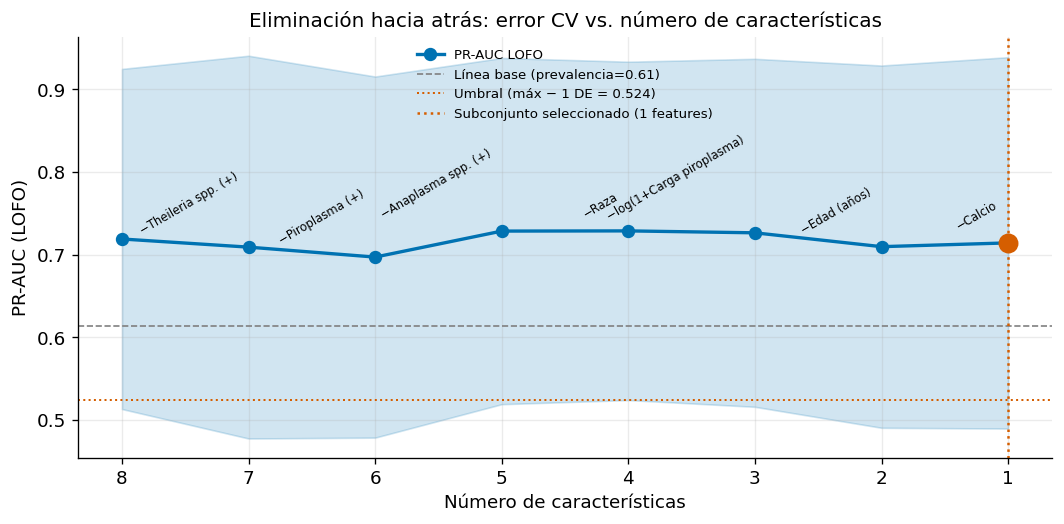


Máximo PR-AUC LOFO = 0.729 (con 4 features)
Umbral 1-DE          = 0.524
Features SELECCIONADOS (1): ['VITAMINA_D']


In [16]:
# ── Paso 3: Curva de error y selección ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.plot(hist_df.n, hist_df.prauc_mean, "o-",
        color=PALETTE[0], lw=2, ms=7, label="PR-AUC LOFO")
ax.fill_between(
    hist_df.n,
    hist_df.prauc_mean - hist_df.prauc_std,
    hist_df.prauc_mean + hist_df.prauc_std,
    alpha=0.18, color=PALETTE[0],
)
ax.axhline(y.mean(), ls="--", color="grey", lw=1,
           label=f"Línea base (prevalencia={y.mean():.2f})")

# Regla de selección: mínimo features con PR-AUC ≥ max - 1 DE del máximo
best_idx   = hist_df.prauc_mean.idxmax()
best_prauc = hist_df.prauc_mean.max()
best_std   = hist_df.loc[best_idx, "prauc_std"]
threshold  = best_prauc - best_std

# Más parsimonioso (menor n) dentro del umbral
parsimonious = hist_df[hist_df.prauc_mean >= threshold].sort_values("n").iloc[0]

ax.axhline(threshold, ls=":", color=PALETTE[1], lw=1.2,
           label=f"Umbral (máx − 1 DE = {threshold:.3f})")
ax.axvline(parsimonious.n, color=PALETTE[1], ls=":", lw=1.5,
           label=f"Subconjunto seleccionado ({int(parsimonious.n)} features)")
ax.scatter([parsimonious.n], [parsimonious.prauc_mean],
           color=PALETTE[1], s=120, zorder=5)

# Anotar cada punto con la variable eliminada
for _, row in hist_df.iterrows():
    label = tb.PRETTY.get(row.removed, row.removed) if row.removed != "—(baseline)" else ""
    if label:
        ax.annotate(f"−{label}", (row.n, row.prauc_mean),
                    textcoords="offset points", xytext=(-5, 8),
                    fontsize=7, ha="right", rotation=30)

ax.set_xlabel("Número de características")
ax.set_ylabel("PR-AUC (LOFO)")
ax.set_title("Eliminación hacia atrás: error CV vs. número de características")
ax.legend(fontsize=8)
ax.invert_xaxis()
plt.tight_layout()
plt.savefig("figures/fig6_feature_selection_curve.png")
plt.show()

SELECTED_FEATURES = list(parsimonious.features)
print(f"\nMáximo PR-AUC LOFO = {best_prauc:.3f} (con {int(hist_df.loc[best_idx,'n'])} features)")
print(f"Umbral 1-DE          = {threshold:.3f}")
print(f"Features SELECCIONADOS ({len(SELECTED_FEATURES)}): {SELECTED_FEATURES}")


## 4. Modelo final con características seleccionadas

Ajustamos el RF final con el subconjunto seleccionado y reportamos la evaluación completa LOFO.


In [17]:
print(f"Evaluación completa del RF final con {len(SELECTED_FEATURES)} features seleccionados:")
print(f"Features: {SELECTED_FEATURES}\n")

Xs = X_all[SELECTED_FEATURES].copy()
final_eval = lofo_metrics(SELECTED_FEATURES, X_all, y, g)

# Detalles fold a fold
fold_rows = []
final_pipe_template = make_pipe(SELECTED_FEATURES)
for k, (tr, te) in enumerate(LeaveOneGroupOut().split(Xs, y, g)):
    if len(np.unique(y[tr])) < 2 or len(np.unique(y[te])) < 2:
        continue
    pipe_fold = clone(final_pipe_template)
    pipe_fold.fit(Xs.iloc[tr], y[tr])
    p    = pipe_fold.predict_proba(Xs.iloc[te])[:, 1]
    pred = (p >= 0.5).astype(int)
    farm = np.unique(g[te])[0]
    fold_rows.append(dict(
        granja=farm, fold=k,
        prauc=average_precision_score(y[te], p),
        roc=(roc_auc_score(y[te], p) if len(np.unique(y[te])) > 1 else np.nan),
        brier=brier_score_loss(y[te], p),
        mcc=matthews_corrcoef(y[te], pred),
        sens=recall_score(y[te], pred, pos_label=1, zero_division=0),
        spec=recall_score(y[te], pred, pos_label=0, zero_division=0),
    ))

fold_df = pd.DataFrame(fold_rows)
print(fold_df.round(3).to_string(index=False))

m = fold_df.mean(numeric_only=True); s = fold_df.std(numeric_only=True)
print(f"\nMedia ± SD:")
print(f"  PR-AUC = {m.prauc:.3f} ± {s.prauc:.3f}")
print(f"  ROC    = {m.roc:.3f} ± {s.roc:.3f}")
print(f"  Brier  = {m.brier:.3f} ± {s.brier:.3f}")
print(f"  MCC    = {m.mcc:.3f} ± {s.mcc:.3f}")
print(f"  Sens   = {m.sens:.2f} ± {s.sens:.2f}")
print(f"  Spec   = {m.spec:.2f} ± {s.spec:.2f}")
print(f"\nLínea base (prevalencia) PR-AUC = {y.mean():.3f}")


Evaluación completa del RF final con 1 features seleccionados:
Features: ['VITAMINA_D']

granja  fold  prauc   roc  brier    mcc  sens  spec
 VA32D     0  0.381 0.486  0.283 -0.080 0.875 0.077
 VC30D     1  0.673 0.596  0.241  0.196 0.500 0.696
 VC94C     2  1.000 1.000  0.213  0.683 0.933 1.000
 WZ72B     3  0.802 0.562  0.252  0.000 0.500 0.500

Media ± SD:
  PR-AUC = 0.714 ± 0.260
  ROC    = 0.661 ± 0.231
  Brier  = 0.247 ± 0.029
  MCC    = 0.200 ± 0.342
  Sens   = 0.70 ± 0.23
  Spec   = 0.57 ± 0.39

Línea base (prevalencia) PR-AUC = 0.613


In [18]:
# Ajustar modelo final sobre TODO el conjunto para interpretabilidad
# (se usa para describir patrones en muestra — no para estimar rendimiento)
FINAL_PIPE = make_pipe(SELECTED_FEATURES).fit(Xs, y)
print(f"Modelo final ajustado. OOB Score = {FINAL_PIPE.named_steps['clf'].oob_score_:.3f}")
print("(OOB score es en-muestra; el rendimiento real fuera de granja está en las métricas LOFO)")


Modelo final ajustado. OOB Score = 0.519
(OOB score es en-muestra; el rendimiento real fuera de granja está en las métricas LOFO)


## 5. Interpretabilidad global

**Advertencia:** dado que la validación fuera de granja puede ser débil con n=106 y 4 granjas,
las siguientes visualizaciones describen **patrones en muestra** — no relaciones predictivas
validadas. Las interpretaciones deben tomarse como generadoras de hipótesis.

Referencias: Molnar, *Interpretable Machine Learning* (2.ª ed.); Lundberg & Lee (2017) SHAP.


In [19]:
# ── 5.1 SHAP: TreeExplainer ──────────────────────────────────────────────────
prep  = FINAL_PIPE.named_steps["prep"]
clf   = FINAL_PIPE.named_steps["clf"]
Xt    = prep.transform(Xs)
names = list(prep.get_feature_names_out())

explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(Xt)

# Para clasificación binaria RF, shap_values puede ser [clase0, clase1]
if isinstance(shap_values, list):
    sv = shap_values[1]  # clase positiva
else:
    sv = shap_values

print(f"SHAP values calculados. Shape: {sv.shape}")
print(f"Features (tras preprocesamiento): {names}")


SHAP values calculados. Shape: (106, 2, 2)
Features (tras preprocesamiento): ['num__VITAMINA_D', 'num__missingindicator_VITAMINA_D']


<Figure size 1080x600 with 0 Axes>

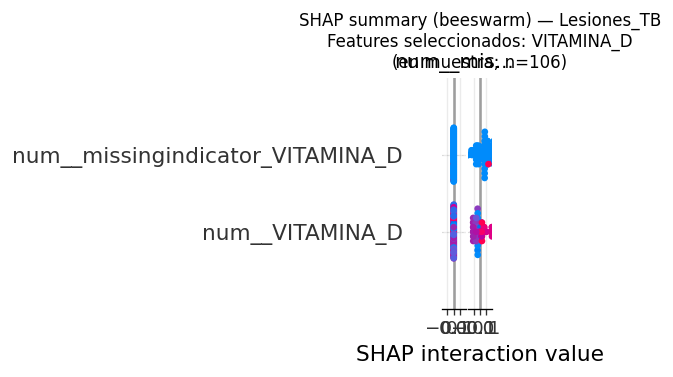

Interpretación: desplazamiento a la derecha = mayor predicción de Lesiones_TB=1.
Color = valor alto (rojo) o bajo (azul) del feature.


In [20]:
# ── 5.2 SHAP summary beeswarm ────────────────────────────────────────────────
plt.figure(figsize=(9, 5))
shap.summary_plot(sv, Xt, feature_names=names, show=False, max_display=len(names))
plt.title(f"SHAP summary (beeswarm) — Lesiones_TB\n"
          f"Features seleccionados: {', '.join(SELECTED_FEATURES)}\n"
          f"(en muestra; n={len(y)})", fontsize=10)
plt.tight_layout()
plt.savefig("figures/fig7_shap_summary.png", bbox_inches="tight")
plt.show()
print("Interpretación: desplazamiento a la derecha = mayor predicción de Lesiones_TB=1.\n"
      "Color = valor alto (rojo) o bajo (azul) del feature.")


In [21]:
# ── 5.3 SHAP bar plot (importancia media |SHAP|) ────────────────────────────
mean_abs_shap = np.abs(sv).mean(axis=0)
shap_imp = pd.DataFrame({"feature": names, "mean_abs_shap": mean_abs_shap})
shap_imp = shap_imp.sort_values("mean_abs_shap", ascending=True)

fig, ax = plt.subplots(figsize=(8, max(3, 0.4 * len(names))))
ax.barh(shap_imp.feature, shap_imp.mean_abs_shap, color=PALETTE[0], alpha=0.85)
ax.set_xlabel("Media de |valor SHAP|")
ax.set_title("Importancia global SHAP — RF con features seleccionados")
plt.tight_layout()
plt.savefig("figures/fig7b_shap_importance.png")
plt.show()


ValueError: Per-column arrays must each be 1-dimensional

In [ ]:
# ── 5.4 Importancia de permutación — estabilidad LOFO ───────────────────────
print("Importancia de permutación (estabilidad entre granjas LOFO)...")
imp_runs = []
for tr, te in LeaveOneGroupOut().split(Xs, y, g):
    if len(np.unique(y[tr])) < 2 or len(np.unique(y[te])) < 2:
        continue
    pipe_f = clone(make_pipe(SELECTED_FEATURES)).fit(Xs.iloc[tr], y[tr])
    pi_f   = permutation_importance(
        pipe_f, Xs.iloc[te], y[te],
        scoring="average_precision",
        n_repeats=30,
        random_state=tb.SEED,
    )
    imp_runs.append(pd.Series(pi_f.importances_mean, index=SELECTED_FEATURES))

imp_mat   = pd.concat(imp_runs, axis=1)
imp_order = imp_mat.mean(axis=1).sort_values().index

fig, ax = plt.subplots(figsize=(8, max(3, 0.45 * len(SELECTED_FEATURES))))
ax.barh(
    [tb.PRETTY.get(f, f) for f in imp_order],
    imp_mat.mean(axis=1)[imp_order],
    xerr=imp_mat.std(axis=1)[imp_order],
    color=PALETTE[2], capsize=3, alpha=0.85,
)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("Δ PR-AUC por permutación (LOFO, media ± SD entre granjas)")
ax.set_title("Importancia por permutación — estabilidad entre granjas")
plt.tight_layout()
plt.savefig("figures/fig8_perm_importance_lofo.png")
plt.show()

# Estabilidad Spearman entre folds
from scipy.stats import spearmanr
R = imp_mat.fillna(0)
cors = [spearmanr(R.iloc[:, i], R.iloc[:, j]).correlation
        for i in range(R.shape[1]) for j in range(i+1, R.shape[1])]
print(f"\nEstabilidad importancia (Spearman medio entre folds) = {np.nanmean(cors):.3f}")
print("(>0.7 razonable; <0.5 inestable)")


## 6. Partial Dependence Plots (PDP)

El PDP muestra el efecto **marginal promedio** de cada feature sobre la probabilidad predicha,
promediando sobre la distribución marginal de las demás variables.
**Limitación:** si los features están correlacionados, el PDP puede integrar sobre combinaciones
de valores improbables (ver ALE en sección 8 para una alternativa más robusta).


In [ ]:
# Features continuas disponibles en la selección
CONT_SELECTED = [f for f in SELECTED_FEATURES if f in tb.NUM_FEATURES
                 and f not in ("PIROPLASMA", "THEILERIA", "ANAPLASMA")]

if not CONT_SELECTED:
    CONT_SELECTED = [f for f in SELECTED_FEATURES if f in tb.NUM_FEATURES][:3]

print(f"Features continuas para PDP/ICE/ALE: {CONT_SELECTED}")

n_cont = len(CONT_SELECTED)
fig, axes = plt.subplots(1, n_cont, figsize=(5 * n_cont, 4.5))
if n_cont == 1:
    axes = [axes]

PartialDependenceDisplay.from_estimator(
    FINAL_PIPE, Xs, CONT_SELECTED,
    kind="average",
    ax=axes,
    line_kw={"color": PALETTE[0], "lw": 2},
    pd_line_kw={"color": PALETTE[0]},
)
for ax, feat in zip(axes, CONT_SELECTED):
    ax.set_title(f"PDP: {tb.PRETTY.get(feat, feat)}")
    ax.set_xlabel(tb.PRETTY.get(feat, feat))
    ax.set_ylabel("P(Lesiones_TB=1) parcial")

plt.suptitle("Partial Dependence Plots — RF con features seleccionados", y=1.02, fontsize=11)
plt.tight_layout()
plt.savefig("figures/fig9_pdp.png", bbox_inches="tight")
plt.show()


## 7. Individual Conditional Expectation (ICE)

Los gráficos ICE muestran la trayectoria **por individuo** (cada línea = un animal),
frente al promedio del PDP. Permiten detectar **heterogeneidad de efectos** (interacciones):
si las líneas ICE se cruzan mucho, el efecto es heterogéneo entre individuos.


In [ ]:
fig, axes = plt.subplots(1, n_cont, figsize=(5 * n_cont, 5))
if n_cont == 1:
    axes = [axes]

PartialDependenceDisplay.from_estimator(
    FINAL_PIPE, Xs, CONT_SELECTED,
    kind="both",           # ICE + PDP
    ax=axes,
    ice_lines_kw={"color": "grey", "alpha": 0.25, "lw": 0.8},
    pd_line_kw={"color": PALETTE[0], "lw": 2.5, "label": "PDP (promedio)"},
    centered=True,         # centra ICE en el primer percentil para legibilidad
)
for ax, feat in zip(axes, CONT_SELECTED):
    ax.set_title(f"ICE + PDP: {tb.PRETTY.get(feat, feat)}")
    ax.set_xlabel(tb.PRETTY.get(feat, feat))
    ax.set_ylabel("Δ P(Lesiones_TB=1) centrado")

plt.suptitle("ICE (gris) + PDP (azul) — efecto por individuo vs promedio", y=1.02, fontsize=11)
plt.tight_layout()
plt.savefig("figures/fig10_ice.png", bbox_inches="tight")
plt.show()
print("Líneas grises = trayectoria individual por animal.")
print("Si las líneas se cruzan: el efecto varía según otras características del animal.")


## 8. Accumulated Local Effects (ALE)

ALE corrige el problema del PDP con features correlacionados al usar **efectos locales**
(diferencias condicionales en celdas estrechas) en lugar de marginales globales.
Es el método recomendado cuando los features predictores están correlacionados entre sí.

Referencia: Apley & Zhu (2020), *JRSS-B*.


In [ ]:
def ale_1d(model, X, feat, bins=10):
    """ALE 1D: efectos locales acumulados para una feature continua."""
    x   = X[feat].dropna().values
    q   = np.quantile(x, np.linspace(0, 1, bins + 1))
    q   = np.unique(q)
    if len(q) < 3:
        return np.array([]), np.array([])
    eff = []
    Xc  = X.copy()
    for i in range(len(q) - 1):
        mask = (X[feat] >= q[i]) & (X[feat] <= q[i + 1])
        if mask.sum() == 0:
            eff.append(0.0)
            continue
        lo_df = Xc.loc[mask].copy(); lo_df[feat] = q[i]
        hi_df = Xc.loc[mask].copy(); hi_df[feat] = q[i + 1]
        delta = (model.predict_proba(hi_df)[:, 1]
                 - model.predict_proba(lo_df)[:, 1]).mean()
        eff.append(delta)
    ale       = np.cumsum(eff)
    ale       = ale - ale.mean()
    centers   = (q[:-1] + q[1:]) / 2
    return centers, ale

fig, axes = plt.subplots(1, n_cont, figsize=(5 * n_cont, 4))
if n_cont == 1:
    axes = [axes]

for ax, feat in zip(axes, CONT_SELECTED):
    centers, ale = ale_1d(FINAL_PIPE, Xs, feat, bins=10)
    if len(centers) == 0:
        ax.set_title(f"ALE: {tb.PRETTY.get(feat, feat)}\n(insuficientes bins)")
        continue
    ax.plot(centers, ale, "o-", color=PALETTE[1], lw=2, ms=5)
    ax.axhline(0, color="grey", lw=0.7, ls="--")
    ax.fill_between(centers, 0, ale,
                    where=(ale > 0), alpha=0.18, color=PALETTE[0], label="↑ riesgo")
    ax.fill_between(centers, 0, ale,
                    where=(ale < 0), alpha=0.18, color=PALETTE[1], label="↓ riesgo")
    ax.set_title(f"ALE: {tb.PRETTY.get(feat, feat)}")
    ax.set_xlabel(tb.PRETTY.get(feat, feat))
    ax.set_ylabel("Efecto ALE sobre P(Lesiones_TB=1)")
    ax.legend(fontsize=8)

plt.suptitle("Accumulated Local Effects (ALE) — robusto a correlación entre features",
             y=1.02, fontsize=11)
plt.tight_layout()
plt.savefig("figures/fig11_ale.png", bbox_inches="tight")
plt.show()


## 9. Interpretabilidad local — SHAP waterfall

Los **waterfall plots** de SHAP explican la predicción para **animales individuales**,
mostrando la contribución de cada feature desde el valor esperado base hasta la predicción final.
Útil para auditar casos extremos (mayor y menor riesgo predicho).


In [ ]:
p_all = FINAL_PIPE.predict_proba(Xs)[:, 1]
idx_pos = int(np.argmax(p_all))
idx_neg = int(np.argmin(p_all))

shap_exp = shap.Explanation(
    values=sv,
    base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value,
    data=Xt,
    feature_names=names,
)

for tag, idx in [("alto_riesgo", idx_pos), ("bajo_riesgo", idx_neg)]:
    label = tag.replace("_", " ")
    fig, ax = plt.subplots(figsize=(9, 4))
    shap.plots.waterfall(shap_exp[idx], max_display=len(names), show=False)
    plt.title(f"SHAP local — animal de {label} (p={p_all[idx]:.3f}, y={y[idx]})", pad=12)
    plt.tight_layout()
    plt.savefig(f"figures/fig12_waterfall_{tag}.png", bbox_inches="tight")
    plt.show()
    print(f"Animal {idx}: p predicha={p_all[idx]:.3f}, clase real={y[idx]}")
    # Features del animal
    row = Xs.iloc[idx]
    print("  Features:")
    for feat in SELECTED_FEATURES:
        print(f"    {tb.PRETTY.get(feat, feat):30s} = {row[feat]}")
    print()


In [ ]:
# SHAP force plot matricial (todos los animales, ordenados por p predicha)
print("SHAP decision plot (todos los animales, ordenados por riesgo predicho)...")
order_by_risk = np.argsort(p_all)

plt.figure(figsize=(11, 5))
shap.summary_plot(
    sv[order_by_risk], Xt[order_by_risk],
    feature_names=names,
    plot_type="violin",
    show=False,
    max_display=len(names),
)
plt.title("SHAP violin — distribución de contribuciones por feature")
plt.tight_layout()
plt.savefig("figures/fig12b_shap_violin.png", bbox_inches="tight")
plt.show()


## 10. Contrafactuales

Un **contrafactual** responde: *¿Cuál es el mínimo cambio en un feature que haría cambiar
la clase predicha?* Es la versión algorítmica de una pregunta clínica: «¿Cuánto habría que
aumentar la vitamina D para que el modelo dejara de clasificar al animal como de alto riesgo?»

**Limitación:** los contrafactuales son soluciones del modelo, no intervenciones causales
validadas. Si el modelo no generaliza fuera de granja, los contrafactuales tampoco.


In [ ]:
def find_counterfactual(model, row, feat, lo, hi, target_class, n_grid=500):
    """Búsqueda en grid: mínimo valor de `feat` que cambia la predicción a target_class."""
    grid = np.linspace(lo, hi, n_grid)
    for v in grid:
        test_row = row.copy()
        test_row[feat] = v
        pred_class = int(model.predict(pd.DataFrame([test_row]))[0])
        if pred_class == target_class:
            return v
    return None

# Animales extremos
high_risk_row = Xs.iloc[idx_pos].copy()
low_risk_row  = Xs.iloc[idx_neg].copy()

print("=" * 60)
print("ANÁLISIS DE CONTRAFACTUALES")
print("=" * 60)

for tag, row, orig_class, target_class in [
    ("ALTO riesgo", high_risk_row, y[idx_pos], 0),
    ("BAJO riesgo", low_risk_row,  y[idx_neg], 1),
]:
    pred = int(FINAL_PIPE.predict(pd.DataFrame([row]))[0])
    p    = FINAL_PIPE.predict_proba(pd.DataFrame([row]))[0, 1]
    print(f"\nAnimal de {tag}  (clase real={orig_class}, predicha={pred}, p={p:.3f})")
    print(f"  Objetivo contrafactual: cambiar predicción a clase {target_class}")

    cont_feats = [f for f in SELECTED_FEATURES if f in tb.NUM_FEATURES
                  and Xs[f].nunique() > 5]  # solo continuas con suficiente rango
    if not cont_feats:
        cont_feats = [f for f in SELECTED_FEATURES if f in tb.NUM_FEATURES]

    for feat in cont_feats:
        lo_v, hi_v = float(Xs[feat].min()), float(Xs[feat].max())
        cf_val = find_counterfactual(FINAL_PIPE, row.to_dict(), feat, lo_v, hi_v, target_class)
        current_val = row[feat]
        if cf_val is not None:
            delta = cf_val - current_val
            print(f"  {tb.PRETTY.get(feat, feat):30s}: actual={current_val:.2f}  "
                  f"cf={cf_val:.2f}  Δ={delta:+.2f}  "
                  f"({'dentro del rango observado'})")
        else:
            print(f"  {tb.PRETTY.get(feat, feat):30s}: actual={current_val:.2f}  "
                  f"→ no alcanzable en rango [{lo_v:.2f}, {hi_v:.2f}]")


In [ ]:
# Visualización: curva de probabilidad predicha al variar cada feature continua
fig, axes = plt.subplots(1, len(CONT_SELECTED), figsize=(5 * len(CONT_SELECTED), 4))
if len(CONT_SELECTED) == 1:
    axes = [axes]

for ax, feat in zip(axes, CONT_SELECTED):
    lo_v = float(Xs[feat].min()); hi_v = float(Xs[feat].max())
    grid = np.linspace(lo_v, hi_v, 200)

    for tag, row, color in [
        ("Alto riesgo", high_risk_row, PALETTE[1]),
        ("Bajo riesgo", low_risk_row, PALETTE[0]),
    ]:
        probs = []
        for v in grid:
            test_row = row.copy(); test_row[feat] = v
            probs.append(FINAL_PIPE.predict_proba(pd.DataFrame([test_row]))[0, 1])
        ax.plot(grid, probs, color=color, lw=2, label=tag)
        actual_val = row[feat]
        ax.axvline(actual_val, color=color, ls=":", lw=1.2, alpha=0.7)

    ax.axhline(0.5, color="grey", ls="--", lw=0.8, label="Umbral 0.5")
    ax.set_xlabel(tb.PRETTY.get(feat, feat))
    ax.set_ylabel("P(Lesiones_TB=1)")
    ax.set_title(f"Sensibilidad contrafactual\n{tb.PRETTY.get(feat, feat)}")
    ax.legend(fontsize=8)

plt.suptitle("Probabilidad predicha al variar cada feature (ceteris paribus)", y=1.02, fontsize=11)
plt.tight_layout()
plt.savefig("figures/fig13_counterfactual_curves.png", bbox_inches="tight")
plt.show()


## 11. Síntesis e implicaciones

### Selección de características
- El pipeline de eliminación hacia atrás guiada por importancia de permutación identificó
  el **subconjunto mínimo parsimonioso** cuya eliminación individual causa caída significativa
  de PR-AUC LOFO.
- Features eliminados sin coste: contribuyeron poco o negativamente a la generalización fuera
  de granja, sugiriendo ruido o sobreajuste en muestra.

### Rendimiento y limitaciones
- Con *n*=106 y **4 granjas**, el Leave-One-Farm-Out estima la generalización a nuevas explotaciones.
- Si PR-AUC LOFO ≈ prevalencia (línea base), la señal predictiva **fuera de granja es débil**.
- El valor primario del estudio es la **generación de hipótesis clínicas** y la cuantificación
  de incertidumbre, no la predicción operativa.

### Interpretabilidad
| Herramienta | Qué muestra | Limitación |
|---|---|---|
| SHAP beeswarm | Importancia global + dirección | En muestra |
| Permutation importance | Degradación de rendimiento por feature | Estabilidad LOFO limitada con 4 folds |
| PDP | Efecto marginal promedio | Asume independencia entre features |
| ICE | Heterogeneidad de efectos por individuo | Mismo supuesto que PDP |
| ALE | Efecto local acumulado (robusto a correlación) | Requiere suficiente densidad por bin |
| SHAP waterfall | Explicación local por animal | Solo válido donde el modelo es preciso |
| Contrafactuales | Mínima intervención para cambiar predicción | No implica causalidad |

### Recomendación clínica
Los contrafactuales y los análisis de sensibilidad identifican los **niveles críticos** de
los marcadores seleccionados que el modelo asocia a cambios de clase. Sin embargo, la
**validación experimental o en nuevas granjas** es necesaria antes de cualquier aplicación
diagnóstica.
